# Week 2 - Day 2 - Hands On Lab
Probability & Distributions in Code

## Objective

In this notebook I practice probability concepts and probability distributions using Python. I implement:

- Coin flip simulation
- Normal distribution sampling
- Conditional probability simulation
- Result interpretation

### 1. Import Libraries

In [136]:
import numpy as np
import matplotlib.pyplot as plt

------------------------------------------------------------------------------------------------------------------------------

### 2. Coin Flip Simulation

Simulate 10,000 coin flips with NumPy and confirm the proportion of heads approaches 0.5.

**Simulation**

In [137]:
n_flips = 10000

flips = np.random.choice(["Heads", "Tails"], size=n_flips)

unique, counts = np.unique(flips, return_counts=True)
results = dict(zip(unique, counts))

results

{np.str_('Heads'): np.int64(4990), np.str_('Tails'): np.int64(5010)}

**Calculate Heads Probability**

In [138]:
heads_probability = results["Heads"] / n_flips
print("Probability of Heads:", heads_probability)

Probability of Heads: 0.499


**Interpretation**

0.498 is very close to 0.5. With only 10,000 flips there's still some 
randomness, but the more flips I run, the closer this number gets to 0.5. 
This is the Law of Large Numbers  the observed result gets closer to the 
true probability as the sample size grows.

-----------------------------------------------------------------------------------------------------------------------------

## 3.Normal Distribution Simulation

Sample from a normal distribution with np.random.normal and plot its histogram to confirm the
bell shape.

**Generate Samples**

In [139]:
samples = np.random.normal(
    loc=0,
    scale=1,
    size=1000
)

samples[:10]

array([-0.70943116,  0.64459543, -0.3824524 , -1.9759633 , -0.57031407,
       -1.17910821,  0.03390272, -1.19040774,  0.9259751 , -0.09107586])

I generate random samples from a normal distribution and check that they form the expected bell shape. A normal distribution is defined by its mean (μ) and standard deviation (σ).

**Visualize Distribution**

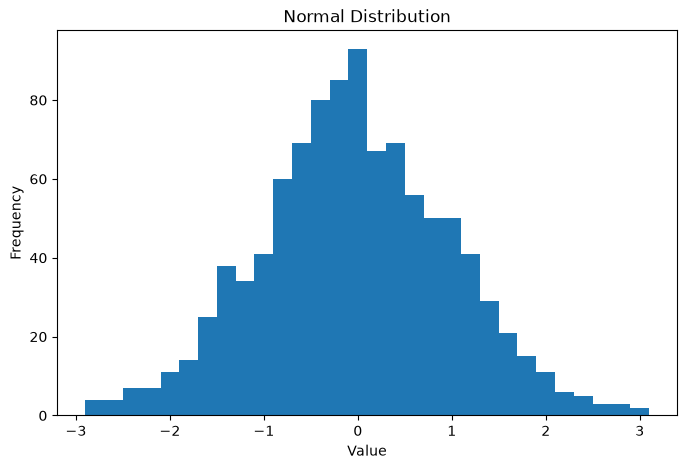

In [140]:
plt.figure(figsize=(8,5))

plt.hist(samples, bins=30)

plt.title("Normal Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")

plt.show()

**Interpretation**

The histogram is bell shaped, with most values close to 0 (the mean) and 
fewer values far from it. This matches what a normal distribution should 
look like.

-------------------------------------------------------------------------------------------------------------------------------

## 4. Conditional Probability Simulation

Given a small worked scenario, compute a conditional probability by hand and verify it with a
simulation.

**Create Simulation Data**

In [141]:
np.random.seed(42)

students = 1000

study_hours = np.random.randint(1, 10, students)

# more study hours -> higher pass probability, so the condition actually matters
pass_probability = np.where(study_hours > 5, 0.8, 0.3)
passed = np.random.binomial(1, pass_probability)

data = np.column_stack((study_hours, passed))

data[:5]

array([[7, 1],
       [4, 0],
       [8, 1],
       [5, 0],
       [7, 1]], dtype=int32)

I simulate a small dataset of students with two events:

A = student passed
B = student studied more than 5 hours

I want P(A | B) - the probability a student passed, given they studied more than 5 hours.

By hand: I build the data so students who study more than 5 hours pass with probability 0.8, and students who study 5 or fewer hours pass with probability 0.3. So before running anything, I already expect P(Pass | Study > 5) to come out close to 0.8.

**Calculate Conditional Probability**

In [143]:
# Students who studied more than 5 hours
condition = study_hours > 5

# Among them, who passed
passed_given_study = passed[condition]

probability = passed_given_study.mean()

print("P(Pass | Study > 5 hours):", probability)
print("Overall pass rate (no condition):", passed.mean())

P(Pass | Study > 5 hours): 0.7953488372093023
Overall pass rate (no condition): 0.514


**Interpretation**

0.795 is close to the 0.8 I expected by hand, so the simulation matches 
my design. It's also clearly higher than the overall pass rate (0.514) - 
which makes sense, since I built more study hours to mean a better chance 
of passing. This is the point of conditional probability: knowing one 
piece of information (study hours) changes the probability of the other 
(passing), instead of just using one average for everyone.

---------------------------------------------------------------------------------------------------------------------------

## 5. Summary of Results

1. Coin Flip Simulation
   - Proportion of heads came out to 0.499, close to the expected 0.5.
   - Shows how randomness settles down with more trials.

2. Normal Distribution
   - Generated data formed a bell shaped histogram.
   - Most values landed close to the mean.

3. Conditional Probability
   - Simulated result (0.795) matched my hand-calculated expectation (0.8).
   - Probability changed once I added the condition, compared to the overall average (0.514).